In [ ]:
# Bài thực hành

In [ ]:
# Bài 1:

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

X shape: torch.Size([190, 10, 1])  y shape: torch.Size([190, 1])
Train: 152, Test: 38


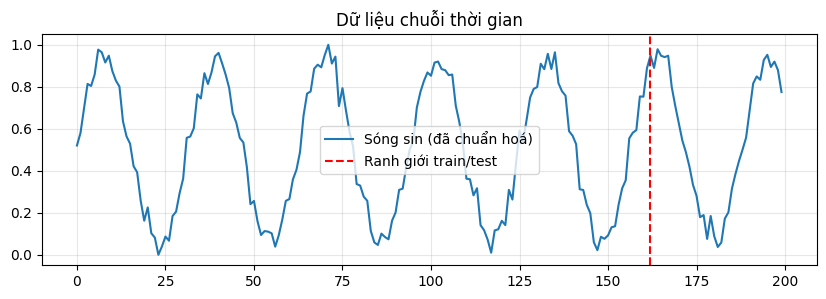

In [13]:
time_steps = 200
x = np.linspace(0, 40, time_steps)
data = np.sin(x) + 0.1 * np.random.randn(time_steps)

# Chuẩn hoá min-max về [0, 1] để output sigmoid hoặc tanh dễ học hơn.
data_min, data_max = data.min(), data.max()
data = (data - data_min) / (data_max - data_min)
data = torch.FloatTensor(data).unsqueeze(1)   # shape (200, 1)

def create_sequences(series, seq_length):
    X, y = [], []
    for i in range(len(series) - seq_length):
        X.append(series[i : i + seq_length])
        y.append(series[i + seq_length])
    return torch.stack(X), torch.stack(y)

seq_length = 10
X, y = create_sequences(data, seq_length)
print('X shape:', X.shape, ' y shape:', y.shape)   # (190, 10, 1) và (190, 1)

# Chia 80/20.
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

# Vẽ chuỗi gốc để có cảm giác về dữ liệu.
plt.figure(figsize=(10, 3))
plt.plot(data.numpy(), label='Sóng sin (đã chuẩn hoá)')
plt.axvline(train_size + seq_length, color='red', linestyle='--', label='Ranh giới train/test')
plt.legend(); plt.grid(alpha=0.3); plt.title('Dữ liệu chuỗi thời gian')
plt.show()

In [14]:
class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # PyTorch tự khởi tạo h0 = 0 nếu mình không truyền vào.
        out, _ = self.rnn(x)             # out shape: (batch, seq_len, hidden_size)
        out = self.fc(out[:, -1, :])     # chỉ lấy bước cuối cùng → (batch, output_size)
        return out

model = RNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
print(model)

RNN(
  (rnn): RNN(1, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=1, bias=True)
)


In [15]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)

num_epochs = 100
loss_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)

    avg_loss = epoch_loss / n_samples
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs}] loss = {avg_loss:.5f}')

Epoch [ 10/100] loss = 0.00300
Epoch [ 20/100] loss = 0.00271
Epoch [ 30/100] loss = 0.00258
Epoch [ 40/100] loss = 0.00329
Epoch [ 50/100] loss = 0.00299
Epoch [ 60/100] loss = 0.00275
Epoch [ 70/100] loss = 0.00305
Epoch [ 80/100] loss = 0.00259
Epoch [ 90/100] loss = 0.00256
Epoch [100/100] loss = 0.00276


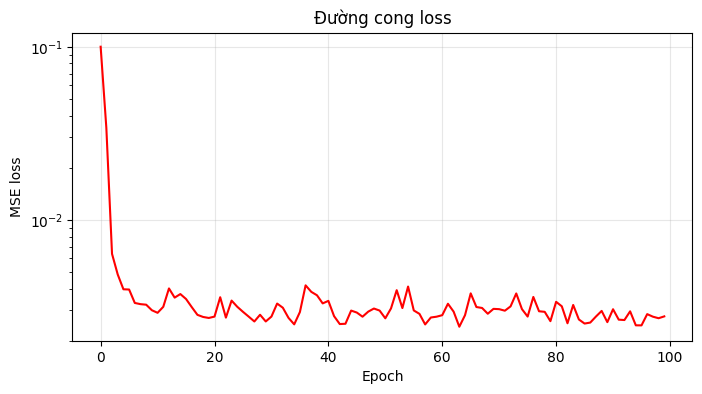

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='red')
plt.xlabel('Epoch'); plt.ylabel('MSE loss'); plt.title('Đường cong loss')
plt.grid(alpha=0.3); plt.yscale('log')
plt.show()

In [17]:
model.eval()
with torch.no_grad():
    pred_one_step = model(X_test).squeeze().numpy()
    truth        = y_test.squeeze().numpy()

mse = np.mean((pred_one_step - truth) ** 2)
mae = np.mean(np.abs(pred_one_step - truth))
print(f'One-step MSE = {mse:.5f},  MAE = {mae:.5f}')

# Baseline ngây thơ: "giá trị tiếp theo bằng giá trị cuối cùng đã thấy".
naive_pred = X_test[:, -1, 0].numpy()
mse_naive = np.mean((naive_pred - truth) ** 2)
print(f'Baseline (naive) MSE = {mse_naive:.5f}  ← RNN phải đánh bại con số này mới gọi là học được gì.')

One-step MSE = 0.00235,  MAE = 0.04097
Baseline (naive) MSE = 0.00600  ← RNN phải đánh bại con số này mới gọi là học được gì.


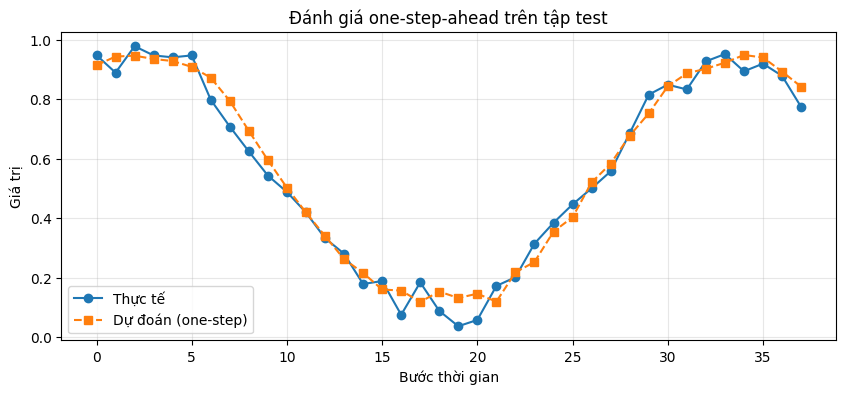

In [18]:
plt.figure(figsize=(10, 4))
plt.plot(truth, 'o-', label='Thực tế')
plt.plot(pred_one_step, 's--', label='Dự đoán (one-step)')
plt.title('Đánh giá one-step-ahead trên tập test')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()


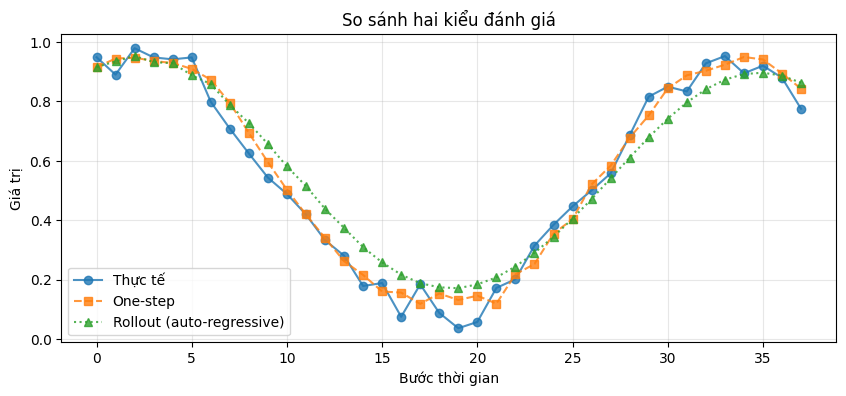

One-step MSE: 0.00235
Rollout  MSE: 0.00604  ← lớn hơn nhiều, đúng như dự đoán.


In [19]:
model.eval()
rollout = []
with torch.no_grad():
    inputs = X_test[0].unsqueeze(0).clone()   # shape (1, 10, 1)
    for _ in range(len(X_test)):
        out = model(inputs)                   # (1, 1)
        rollout.append(out.item())
        # Đẩy out vào cuối, bỏ phần tử đầu — cửa sổ trượt 1 bước.
        next_step = out.unsqueeze(0)          # (1, 1, 1)
        inputs = torch.cat([inputs[:, 1:, :], next_step], dim=1)

rollout = np.array(rollout)

plt.figure(figsize=(10, 4))
plt.plot(truth,           'o-', label='Thực tế', alpha=0.8)
plt.plot(pred_one_step,   's--', label='One-step', alpha=0.8)
plt.plot(rollout,         '^:', label='Rollout (auto-regressive)', alpha=0.8)
plt.title('So sánh hai kiểu đánh giá')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f'One-step MSE: {mse:.5f}')
print(f'Rollout  MSE: {np.mean((rollout - truth)**2):.5f}  ← lớn hơn nhiều, đúng như dự đoán.')

In [ ]:
# Bài tập về nhà

In [ ]:
# Bài tập 1:

   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


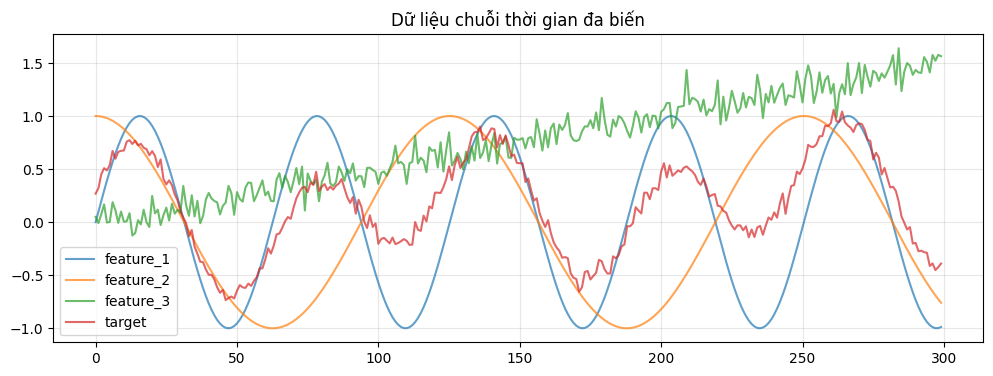

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)
feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target,
})
print(df.head())

plt.figure(figsize=(12, 4))
for col in df.columns:
    plt.plot(df[col], label=col, alpha=0.7)
plt.legend(); plt.grid(alpha=0.3)
plt.title('Dữ liệu chuỗi thời gian đa biến')
plt.show()

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

# 1. Chia tập dữ liệu theo tỷ lệ 70% Train, 15% Val, 15% Test (Theo thứ tự thời gian)
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

# 2. Chuẩn hóa dữ liệu bằng MinMaxScaler (Chỉ fit trên train để tránh data leakage)
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

# 3. Hàm tạo cửa sổ trượt (sliding window) cho dữ liệu đa biến
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length), :3])  # Lấy 3 đặc trưng đầu làm input
        y.append(data[i + seq_length, 3])       # Lấy biến target (cột chỉ số 3) làm output
    return np.array(X), np.array(y)

seq_length = 20
X_train, y_train = create_sequences(train_scaled, seq_length)
X_val, y_val = create_sequences(val_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

# Chuyển đổi sang PyTorch Tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.FloatTensor(y_val).view(-1, 1)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test).view(-1, 1)

# Tạo DataLoader để train theo mini-batch (Giữ shuffle=False vì là chuỗi thời gian)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=16, shuffle=False)

print(f"Khởi tạo xong dữ liệu:")
print(f"-> Train shape: {X_train_t.shape} | Val shape: {X_val_t.shape} | Test shape: {X_test_t.shape}")

Khởi tạo xong dữ liệu:
-> Train shape: torch.Size([190, 20, 3]) | Val shape: torch.Size([25, 20, 3]) | Test shape: torch.Size([25, 20, 3])


Epoch 025/150 | Train Loss: 0.002671 | Val Loss: 0.001466
Epoch 050/150 | Train Loss: 0.001367 | Val Loss: 0.001386
Epoch 075/150 | Train Loss: 0.001530 | Val Loss: 0.001580
Epoch 100/150 | Train Loss: 0.001537 | Val Loss: 0.002666
Epoch 125/150 | Train Loss: 0.001196 | Val Loss: 0.001682
Epoch 150/150 | Train Loss: 0.002026 | Val Loss: 0.003397


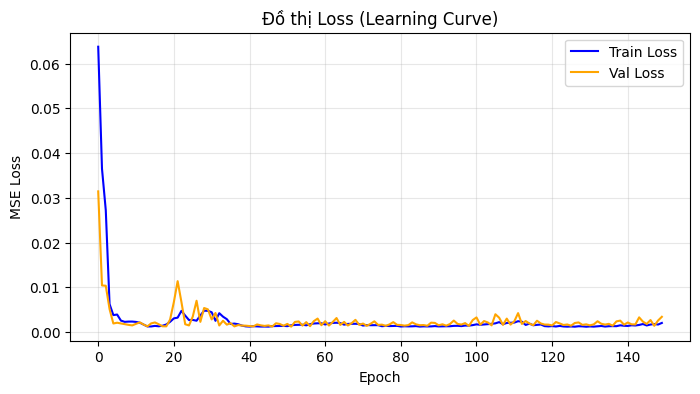

In [4]:
# 1. Định nghĩa cấu trúc mạng RNN đa biến
class MultivariateRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout=0.0):
        super(MultivariateRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # out shape: (batch_size, seq_length, hidden_size)
        out, _ = self.rnn(x)
        # Lấy hidden state của time step cuối cùng để dự báo
        out = self.fc(out[:, -1, :])
        return out

# Khởi tạo thiết bị chạy (Ưu tiên GPU nếu có)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MultivariateRNN(input_size=3, hidden_size=32, output_size=1).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# 2. Vòng lặp huấn luyện trong 150 Epoch
epochs = 150
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    batch_losses = []
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    # Đánh giá trên tập Validation cuối mỗi epoch
    model.eval()
    with torch.no_grad():
        val_X, val_y = X_val_t.to(device), y_val_t.to(device)
        val_preds = model(val_X)
        val_loss = criterion(val_preds, val_y)

    train_losses.append(np.mean(batch_losses))
    val_losses.append(val_loss.item())

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train Loss: {train_losses[-1]:.6f} | Val Loss: {val_losses[-1]:.6f}")

# Vẽ đồ thị Loss qua các Epoch
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.title('Đồ thị Loss (Learning Curve)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST:
Chỉ số       | Mô hình RNN     | Baseline Naive 
--------------------------------------------------
MSE          | 0.00381         | 0.00693        
MAE          | 0.04452         | 0.06607        



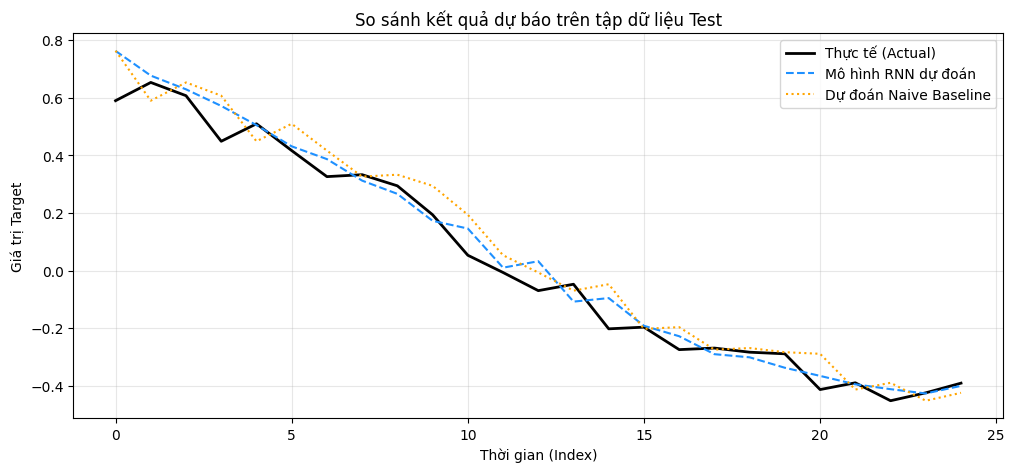

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Dự đoán trên tập Test
model.eval()
with torch.no_grad():
    test_preds_scaled = model(X_test_t.to(device)).cpu().numpy()

# Hàm nghịch đảo chuỗi target về lại thang đo gốc ban đầu
def unnormalize_target(scaled_preds, scaler_obj):
    dummy = np.zeros((len(scaled_preds), 4))
    dummy[:, 3] = scaled_preds.flatten()
    return scaler_obj.inverse_transform(dummy)[:, 3]

actual_target = df.iloc[val_end + seq_length:]['target'].values
predicted_target = unnormalize_target(test_preds_scaled, scaler)

# 2. Xây dựng Naive Baseline (Giá trị bước tiếp theo = giá trị ngay trước đó)
naive_pred = df.iloc[val_end + seq_length - 1 : -1]['target'].values

# 3. Tính toán các chỉ số lỗi
model_mse = mean_squared_error(actual_target, predicted_target)
model_mae = mean_absolute_error(actual_target, predicted_target)

naive_mse = mean_squared_error(actual_target, naive_pred)
naive_mae = mean_absolute_error(actual_target, naive_pred)

print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST:")
print(f"{'Chỉ số':<12} | {'Mô hình RNN':<15} | {'Baseline Naive':<15}")
print("-" * 50)
print(f"{'MSE':<12} | {model_mse:<15.5f} | {naive_mse:<15.5f}")
print(f"{'MAE':<12} | {model_mae:<15.5f} | {naive_mae:<15.5f}\n")

# 4. Vẽ biểu đồ so sánh kết quả trực quan
plt.figure(figsize=(12, 5))
plt.plot(actual_target, label='Thực tế (Actual)', color='black', linewidth=2)
plt.plot(predicted_target, label='Mô hình RNN dự đoán', color='dodgerblue', linestyle='--')
plt.plot(naive_pred, label='Dự đoán Naive Baseline', color='orange', linestyle=':')
plt.title('So sánh kết quả dự báo trên tập dữ liệu Test')
plt.xlabel('Thời gian (Index)')
plt.ylabel('Giá trị Target')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [6]:
# Hàm đóng gói quy trình huấn luyện nhanh để thử nghiệm siêu tham số
def experiment_rnn(seq_len=20, hidden_sz=32, num_layers=1, dropout=0.0):
    X_tr, y_tr = create_sequences(train_scaled, seq_len)
    X_vl, y_vl = create_sequences(val_scaled, seq_len)

    X_tr_t = torch.FloatTensor(X_tr).to(device)
    y_tr_t = torch.FloatTensor(y_tr).view(-1, 1).to(device)
    X_vl_t = torch.FloatTensor(X_vl).to(device)
    y_vl_t = torch.FloatTensor(y_vl).view(-1, 1).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=16, shuffle=False)
    exp_model = MultivariateRNN(input_size=3, hidden_size=hidden_sz, output_size=1,
                                num_layers=num_layers, dropout=dropout).to(device)

    opt = torch.optim.Adam(exp_model.parameters(), lr=0.005)
    crit = nn.MSELoss()

    for epoch in range(100):  # Chạy 100 epoch để kiểm thử nhanh hiệu năng siêu tham số
        exp_model.train()
        for bx, by in loader:
            opt.zero_grad()
            crit(exp_model(bx), by).backward()
            opt.step()

    exp_model.eval()
    with torch.no_grad():
        final_train_loss = crit(exp_model(X_tr_t), y_tr_t).item()
        final_val_loss = crit(exp_model(X_vl_t), y_vl_t).item()
    return final_train_loss, final_val_loss

# Thực hiện in kết quả phân tích
print("--- THỬ NGHIỆM ĐÁNH GIÁ CÁC SIÊU THAM SỐ (PHẦN D) ---")
print("\n1. Thử nghiệm thay đổi seq_length (Cửa sổ trượt):")
for s in [10, 20, 30]:
    t_l, v_l = experiment_rnn(seq_len=s)
    print(f"   seq_length = {s:<2} -> Train Loss: {t_l:.5f} | Val Loss: {v_l:.5f}")

print("\n2. Thử nghiệm thay đổi hidden_size (Kích thước ẩn):")
for h in [16, 32, 64]:
    t_l, v_l = experiment_rnn(hidden_sz=h)
    print(f"   hidden_size = {h:<2} -> Train Loss: {t_l:.5f} | Val Loss: {v_l:.5f}")

print("\n3. Thử nghiệm kết hợp Stacked RNN (2 layers) + Dropout (0.2):")
t_l, v_l = experiment_rnn(num_layers=2, dropout=0.2)
print(f"   2 Layers + Dropout=0.2 -> Train Loss: {t_l:.5f} | Val Loss: {v_l:.5f}")

--- THỬ NGHIỆM ĐÁNH GIÁ CÁC SIÊU THAM SỐ (PHẦN D) ---

1. Thử nghiệm thay đổi seq_length (Cửa sổ trượt):
   seq_length = 10 -> Train Loss: 0.00101 | Val Loss: 0.00132
   seq_length = 20 -> Train Loss: 0.00220 | Val Loss: 0.00213
   seq_length = 30 -> Train Loss: 0.00299 | Val Loss: 0.00477

2. Thử nghiệm thay đổi hidden_size (Kích thước ẩn):
   hidden_size = 16 -> Train Loss: 0.00104 | Val Loss: 0.00126
   hidden_size = 32 -> Train Loss: 0.00162 | Val Loss: 0.00157
   hidden_size = 64 -> Train Loss: 0.00309 | Val Loss: 0.00176

3. Thử nghiệm kết hợp Stacked RNN (2 layers) + Dropout (0.2):
   2 Layers + Dropout=0.2 -> Train Loss: 0.00262 | Val Loss: 0.00235


In [ ]:
# Bài tập 2

In [7]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Thiết lập seed cố định để đảm bảo kết quả đồng nhất
torch.manual_seed(42)
np.random.seed(42)

# 1. Tạo chuỗi sin có 500 điểm dữ liệu gốc
total_points = 500
t_sin = np.linspace(0, 50, total_points)
sin_data = np.sin(t_sin)

# Hàm chuẩn bị dữ liệu theo seq_length cụ thể
def get_rnn_data(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len])
    # Dữ liệu cho RNN đơn biến cần shape: (num_samples, seq_len, input_size=1)
    X_t = torch.FloatTensor(np.array(X)).unsqueeze(-1)
    y_t = torch.FloatTensor(np.array(y)).view(-1, 1)
    return X_t, y_t

# 2. Xây dựng lớp mô hình RNN cơ bản với hidden_size = 8
class VanishingRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=8, output_size=1):
        super(VanishingRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # out: (batch_size, seq_len, hidden_size)
        out, _ = self.rnn(x)
        return out, self.fc(out)  # Trả về cả chuỗi ẩn đầu ra và dự đoán cuối cùng

print("Đã khởi tạo xong dữ liệu mẫu và kiến trúc mô hình mạng cho Bài tập 2.")

Đã khởi tạo xong dữ liệu mẫu và kiến trúc mô hình mạng cho Bài tập 2.


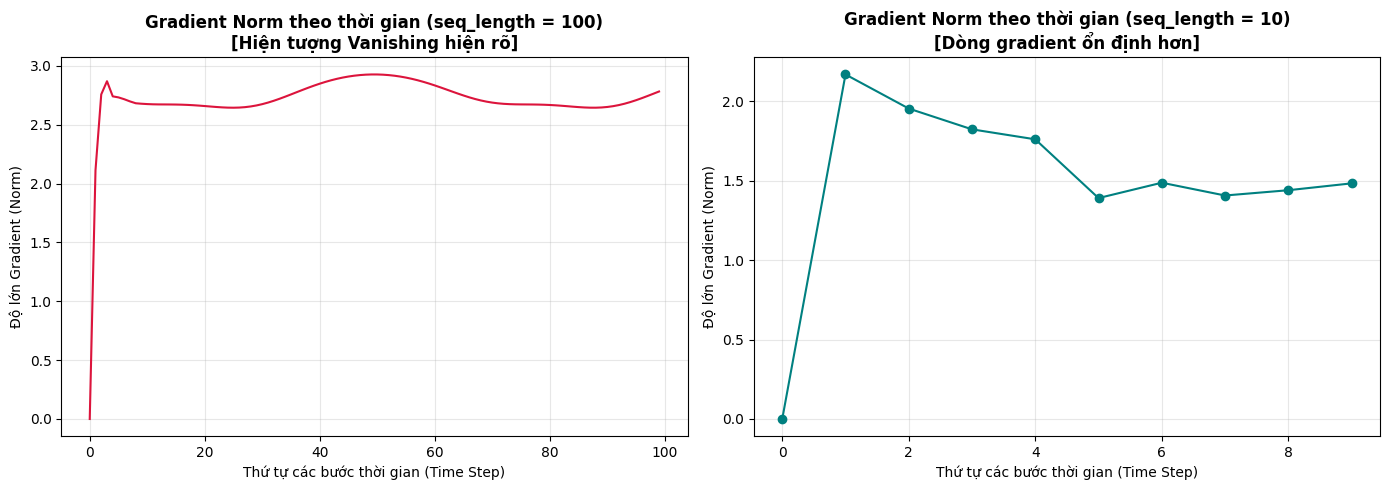

In [9]:
def calculate_gradients_per_step(seq_len):
    # Lấy dữ liệu với seq_length tương ứng
    X_t, y_t = get_rnn_data(sin_data, seq_len)

    # Khởi tạo mô hình mới và hàm loss
    model_v = VanishingRNN()
    criterion = nn.MSELoss()

    # Chỉ lấy một mẫu dữ liệu duy nhất để quan sát gradient rõ ràng nhất
    sample_x = X_t[0:1] # shape (1, seq_len, 1)
    sample_y = y_t[0:1] # shape (1, 1)

    # Feedforward
    rnn_out, total_pred = model_v(sample_x)

    # SỬA LỖI WARNING: Chỉ lấy duy nhất time-step cuối cùng để tính loss với y_target đơn biến
    final_pred = total_pred[:, -1, :] # Lấy phần tử cuối cùng -> shape (1, 1)

    # Tính loss
    loss = criterion(final_pred, sample_y)

    gradient_norms = []

    # Đi lùi từ time-step cuối cùng (bước gần nhất) về đầu chuỗi (bước xa nhất)
    for t in reversed(range(seq_len)):
        model_v.zero_grad()

        # Gọi backward độc lập tại time step thứ t
        rnn_out[0, t, :].backward(torch.ones_like(rnn_out[0, t, :]), retain_graph=True)

        # Đọc độ lớn (norm) của gradient tại trọng số ma trận ẩn lặp rnn.weight_hh_l0
        grad_norm = model_v.rnn.weight_hh_l0.grad.norm().item()
        gradient_norms.append(grad_norm)

    # Đảo lại danh sách để đúng thứ tự từ bước đầu chuỗi đến bước cuối cùng
    gradient_norms.reverse()
    return gradient_norms

# Chạy thực nghiệm với hai cấu hình seq_length khác nhau
grad_norms_100 = calculate_gradients_per_step(seq_len=100)
grad_norms_10 = calculate_gradients_per_step(seq_len=10)

# SỬA LỖI ATTRIBUTEERROR: Loại bỏ cấu hình fontdict bất hợp pháp trong plt.plot
plt.figure(figsize=(14, 5))

# Biểu đồ cho chuỗi dài seq_length = 100
plt.subplot(1, 2, 1)
plt.plot(grad_norms_100, color='crimson')
plt.title('Gradient Norm theo thời gian (seq_length = 100)\n[Hiện tượng Vanishing hiện rõ]', fontsize=12, fontweight='bold')
plt.xlabel('Thứ tự các bước thời gian (Time Step)')
plt.ylabel('Độ lớn Gradient (Norm)')
plt.grid(alpha=0.3)

# Biểu đồ cho chuỗi ngắn seq_length = 10
plt.subplot(1, 2, 2)
plt.plot(grad_norms_10, color='teal', marker='o')
plt.title('Gradient Norm theo thời gian (seq_length = 10)\n[Dòng gradient ổn định hơn]', fontsize=12, fontweight='bold')
plt.xlabel('Thứ tự các bước thời gian (Time Step)')
plt.ylabel('Độ lớn Gradient (Norm)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Bài 3:

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Đảm bảo thiết lập cấu hình độ dài cửa sổ trượt seq_length = 10 theo đúng yêu cầu bài 3
seq_len_b3 = 10

# Chuẩn bị dữ liệu chuỗi thời gian dựa trên sin_data đã có ở Bài tập 2
X_b3, y_b3 = get_rnn_data(sin_data, seq_len_b3)

# Chia tách tập dữ liệu: 80% để Train và 20% giữ lại làm Test (theo thứ tự thời gian)
split = int(len(X_b3) * 0.8)
X_train_b3, y_train_b3 = X_b3[:split], y_b3[:split]
X_test_b3, y_test_b3 = X_b3[split:], y_b3[split:]

# Khởi tạo DataLoader quản lý các mini-batch cho tập Train
train_loader_b3 = DataLoader(TensorDataset(X_train_b3, y_train_b3), batch_size=16, shuffle=False)

# --- 1. Kiến trúc mô hình mạng RNN ---
class SimpleRNN(nn.Module):
    def __init__(self):
        super(SimpleRNN, self).__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=8, batch_first=True)
        self.fc = nn.Linear(8, 1)

    def forward(self, x):
        # out shape: (batch_size, seq_len, hidden_size)
        out, _ = self.rnn(x)
        # Lấy hidden state tại time-step cuối cùng của chuỗi trượt để đưa qua lớp Dense dự báo
        return self.fc(out[:, -1, :])

# --- 2. Kiến trúc mô hình mạng ANN (MLP duỗi phẳng đầu vào) ---
class SimpleANN(nn.Module):
    def __init__(self):
        super(SimpleANN, self).__init__()
        self.flatten = nn.Flatten()
        # Tiếp nhận đầu vào là một vector phẳng 10 chiều (seq_length = 10)
        self.fc1 = nn.Linear(10 * 1, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

# Hàm tổng quát hóa vòng lặp huấn luyện mạng PyTorch cho Bài tập 3
def train_model_b3(model_obj, lr=0.01, epochs=50):
    optimizer = torch.optim.Adam(model_obj.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model_obj.train()
        for bx, by in train_loader_b3:
            optimizer.zero_grad()
            output = model_obj(bx)
            loss = criterion(output, by)
            loss.backward()
            optimizer.step()
    return model_obj

# Tiến hành chạy huấn luyện độc lập cho cả hai mô hình học sâu
rnn_model = train_model_b3(SimpleRNN())
ann_model = train_model_b3(SimpleANN())

print("Đã hoàn tất huấn luyện thành công mô hình RNN và mô hình ANN cho Bài tập 3.")

Đã hoàn tất huấn luyện thành công mô hình RNN và mô hình ANN cho Bài tập 3.


In [11]:
from sklearn.metrics import mean_squared_error

# Đưa mô hình về trạng thái đánh giá độc lập (Evaluation mode)
rnn_model.eval()
ann_model.eval()

with torch.no_grad():
    # Tiến hành dự báo trên tập dữ liệu Test riêng của Bài 3
    rnn_preds = rnn_model(X_test_b3).numpy()
    ann_preds = ann_model(X_test_b3).numpy()

# 3. Thuật toán Baseline Naive cho Bài tập 3:
# Định nghĩa: Giá trị bước thời gian kế tiếp = giá trị điểm cuối cùng của cửa sổ trượt hiện tại.
# X_test_b3 có hình dạng shape (samples, seq_len=10, input_size=1), lấy phần tử index [-1, 0]
naive_preds = X_test_b3[:, -1, 0].numpy()

# Đọc mảng giá trị thực tế trên tập kiểm thử
y_true_b3 = y_test_b3.numpy()

# Tính toán chỉ số lỗi MSE cho cả 3 phương pháp
mse_rnn = mean_squared_error(y_true_b3, rnn_preds)
mse_ann = mean_squared_error(y_true_b3, ann_preds)
mse_naive = mean_squared_error(y_true_b3, naive_preds)

# Hàm bổ trợ đếm tổng số lượng tham số có thể huấn luyện (Trainable parameters)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Xuất bảng báo cáo đối sánh hiệu năng trực quan
print("KẾT QUẢ SO SÁNH MSE ONE-STEP VÀ SỐ LƯỢNG THAM SỐ (BÀI TẬP 3):")
print("-" * 68)
print(f"{'Kiến trúc Mô hình / Thuật toán':<25} | {'Số lượng tham số':<20} | {'MSE One-step':<15}")
print("-" * 68)
print(f"{'1. Mạng RNN':<25} | {count_parameters(rnn_model):<20} | {mse_rnn:<15.6f}")
print(f"{'2. Mạng ANN (MLP)':<25} | {count_parameters(ann_model):<20} | {mse_ann:<15.6f}")
print(f"{'3. Baseline Naive':<25} | {'0 (Không có)':<20} | {mse_naive:<15.6f}")
print("-" * 68)

KẾT QUẢ SO SÁNH MSE ONE-STEP VÀ SỐ LƯỢNG THAM SỐ (BÀI TẬP 3):
--------------------------------------------------------------------
Kiến trúc Mô hình / Thuật toán | Số lượng tham số     | MSE One-step   
--------------------------------------------------------------------
1. Mạng RNN               | 97                   | 0.000019       
2. Mạng ANN (MLP)         | 97                   | 0.000015       
3. Baseline Naive         | 0 (Không có)         | 0.005134       
--------------------------------------------------------------------
